# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Based on the Materials and Methods section of the USING DATA MINING FOR BANK DIRECT MARKETING: AN APPLICATION OF THE CRISP-DM METHODOLOGY paper, "the dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts."

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# First we check for missing values (NaN) and data types
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Based on the output above there are no NaN or nulls in any of the columns, which seems great on the surface but requires investigation and validation. Looking back at the head() output it looks like some of the columns use 'unknown' rather than NaN.

In [6]:
# We include both 'object' and 'str' to suppress a FutureWarning in pandas 2.0
for col in df.select_dtypes(include=['object', 'str']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} 'unknown' values")

job: 330 'unknown' values
marital: 80 'unknown' values
education: 1731 'unknown' values
default: 8597 'unknown' values
housing: 990 'unknown' values
loan: 990 'unknown' values


In [7]:
# Dropping the 'duration' column to prevent data leakage, as instructed by the dataset documentation
df = df.drop('duration', axis=1)

print("Shape of dataset after dropping 'duration':", df.shape)

Shape of dataset after dropping 'duration': (41188, 20)


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  str    
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null  float64
 1

The dataset contains the results from 17 direct telemarketing campaigns completed by a (Portuguese) bank. The goal of the bank was to convince people being called to subscribe to a term deposit (this is the target variable y in the data). 
The dataset also gives us a number of specific client attributes like age, job, marital status, and education. Also included are social and economic indicators like consumer price index, and employment variation rate.
The commercial context here is telemarketing, which is resource-intensive; calling clients without a targeted strategy wastes time, costs money, and can annoy customers.
The clearly stated goal of this project is comparing the performance of four different classifiers: K-Nearest Neighbors, Logistic Regression, Decision Trees, and Support Vector Machines. The comparison will be used to determine the algorithm that best predicts whether a client will subscribe to a term deposit (convert).
Through this analysis we will identify the characteristics of clients who are most likely to convert, which can be used to create a targeted call list for the bank's marketing team. This predictive model will enable the bank to increase conversion rates, reduce costs, and improve customer experience.

### Exploratory Data Analysis
Before engineering our features we have to understand the underlying data distribution. Specifically, we need to examine the class imbalance in our target variable, the age distribution of our clients, and how conversion differences between job categories.

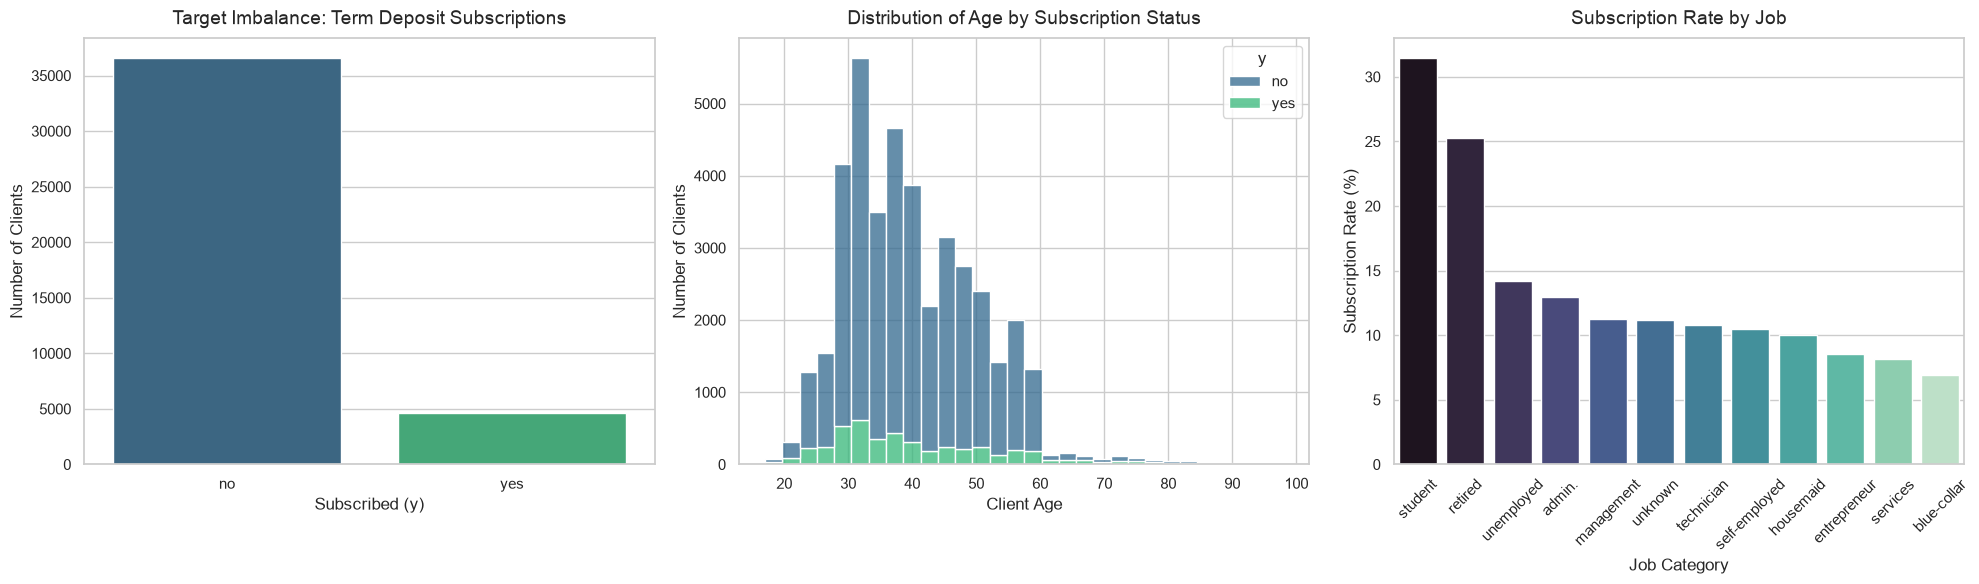

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# First we set up the visualization style
sns.set_theme(style="whitegrid")

# Then we create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Next we create Plot 1 Target Imbalance (The 'y' variable)
sns.countplot(data=df, x='y', hue='y', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Target Imbalance: Term Deposit Subscriptions", fontsize=14, pad=10)
axes[0].set_xlabel("Subscribed (y)", fontsize=12)
axes[0].set_ylabel("Number of Clients", fontsize=12)

# Create Plot 2 Continuous Variable (Age Distribution)
sns.histplot(data=df, x='age', hue='y', multiple="stack", bins=30, ax=axes[1], palette="viridis")
axes[1].set_title("Distribution of Age by Subscription Status", fontsize=14, pad=10)
axes[1].set_xlabel("Client Age", fontsize=12)
axes[1].set_ylabel("Number of Clients", fontsize=12)

# Create Plot 3 Categorical Variable (Job vs. Subscription)
job_conversion = df.groupby('job')['y'].value_counts(normalize=True).unstack()
job_conversion = (job_conversion.sort_values(by='yes', ascending=False) * 100)

# Finally we set the second plot to be a bar plot of the subscription rate by job category
sns.barplot(x=job_conversion.index, y=job_conversion['yes'], hue=job_conversion.index, legend=False, ax=axes[2], palette="mako")
axes[2].set_title("Subscription Rate by Job", fontsize=14, pad=10)
axes[2].set_xlabel("Job Category", fontsize=12)
axes[2].set_ylabel("Subscription Rate (%)", fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [10]:
# Fist let's define the specific 'bank client data' features requested, removing the economic indicators and campaign information features
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

In [11]:
# Assign the predictor variables to 'X'
X = df[bank_features]

In [12]:
# Next we encode the target variable (y) into binary integers (0 and 1)
y = df['y'].map({'no': 0, 'yes': 1})

In [13]:
# Convert categorical variables into numerical dummy variables by using drop_first=True to avoid the issues with dummy variable multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

In [14]:
# Check to see what the data looks like after the encoding
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)
X_encoded.head()

Original X shape: (41188, 7)
Encoded X shape: (41188, 28)


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,37,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,56,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [15]:
# Firt in order to split the data we first need to import the train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split

In [16]:
# Next we'll split the data into 70% training and 30% testing
# Just as we've done throughout the course we'll use random_state=42 as the seed so we get the exact same split every time we run the cell
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

In [17]:
# Finally we check the shapes to verify our split worked correctly
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28831, 28)
X_test shape: (12357, 28)
y_train shape: (28831,)
y_test shape: (12357,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [18]:
# Find the count of the most frequent class (either 0 or 1) in our training target
majority_class_count = y_train.value_counts().max()

In [19]:
# Let's find the total number of items in our training data
total_train_count = len(y_train)

In [20]:
# Using the above values calculate the baseline accuracy percentage
baseline_accuracy = majority_class_count / total_train_count

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.8872


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [21]:
# First we need to import the LogisticRegression model and the accuracy_score function
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [22]:
# Next we initialize the model, adding max_iter=1000 to prevent a common scikit-learn warning about convergence
log_reg = LogisticRegression(max_iter=1000)

In [ ]:
# Then we fit (train) the model on the training data
log_reg.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [24]:
# Now let's make predictions on the (unseen) testing data
y_pred = log_reg.predict(X_test)

In [ ]:
# Last we calculate our model's accuracy and print the results
model_accuracy = accuracy_score(y_test, y_pred)

print(f"Basic Logistic Regression Accuracy: {model_accuracy:.4f}")

Basic Logistic Regression Accuracy: 0.8876


### Problem 9: Score the Model

What is the accuracy of your model?

In [26]:
# Let's calculate the training accuracy to compare against our test accuracy
train_preds = log_reg.predict(X_train)
train_accuracy = accuracy_score(y_train, train_preds)

print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
print(f"Logistic Regression Test Accuracy: {model_accuracy:.4f}")

Logistic Regression Train Accuracy: 0.8872
Logistic Regression Test Accuracy: 0.8876


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [27]:
#Fist let's import the necessary libraries for the models
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [28]:
# Next we initialize the four models with default settings keeping max_iter=1000 for Logistic Regression to prevent convergence warnings)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

In [29]:
# Next we create an empty list to store our results
results = []

In [ ]:
# Next we loop through the models, capturing the training time, training accuracy, and testing accuracy for each model in a dictionary and appending it to our results list
print("Starting to loop through the models, this may take a few minutes...")
for model_name, model in models.items():
    
    # Start the timer so we can calculate the training time for each model
    start_time = time.time()
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Stop the timer and determine the training time
    end_time = time.time()
    train_time = end_time - start_time
    
    # Predict and score training data
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    # Predict and score testing data
    test_preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    
    # Append the data to our results list as a dictionary
    results.append({
        'Model': model_name,
        'Train Time': train_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

In [31]:
# Finally we convert the results list into a pandas DataFrame and show the results
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.574083,0.887239,0.887594
1,KNN,0.006663,0.890153,0.877964
2,Decision Tree,0.172067,0.917970,0.863559
3,SVM,10.456046,0.887239,0.887594


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

#### Rationale for Evaluation Metric
For this question we will be switching the evaluation metric from basic accuracy to ROC-AUC (Receiver Operating Characteristic - Area Under Curve).

The change is because our dataset has a noticeable class imbalance. Specifically, the majority of clients called did not subscribe to the term deposit. If we used a basic accuracy a model, the model could simply predict "no" for every single client and achieve 89% accuracy. The accuracy would be impressively high, but the model fails at the actual business objective: identifying clients most likely to subscribe to the term deposit.

ROC-AUC shows whether a model distinguishes between clients who respond 'yes' (subscribers) and clients who respond 'no' (non-subscribers). A higher ROC-AUC score tells us the model is actually learning the characteristics of the subscribers in the dataset, instead of guessing the majority class.

In [32]:
# Start by importing the necessary libraries for the models
from sklearn.model_selection import GridSearchCV

In [33]:
# Define the parameter grid (the settings we want the computer to test)using max_depth controls how deep the tree grows (preventing it from memorizing the data)
tree_params = {
    'max_depth': [2, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

In [34]:
# Initialize a fresh Decision Tree
dtree = DecisionTreeClassifier(random_state=42)

In [35]:
# Setup GridSearchCV using cv=5 for 5-fold cross-validation.
# We explicitly change our scoring metric here to handle the class imbalance
grid_tree = GridSearchCV(dtree, tree_params, cv=5, scoring='roc_auc')

In [36]:
# We fit the grid search to our training data which runs all the combinations
grid_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [37]:
# Finally we output the winning results
print("Best Decision Tree Parameters:", grid_tree.best_params_)
print(f"Best Training ROC-AUC Score: {grid_tree.best_score_:.4f}")

Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best Training ROC-AUC Score: 0.6463


In [38]:
# Tune K-Nearest Neighbors
print("Starting KNN Grid Search...")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn = KNeighborsClassifier()

# cv=5 for 5-fold cross validation, scoring='roc_auc'
grid_knn = GridSearchCV(knn, knn_params, cv=5, scoring='roc_auc')
grid_knn.fit(X_train, y_train)

print("Best KNN Parameters:", grid_knn.best_params_)
print(f"Best KNN Training ROC-AUC: {grid_knn.best_score_:.4f}\n")

Starting KNN Grid Search...
Best KNN Parameters: {'n_neighbors': 11}
Best KNN Training ROC-AUC: 0.6053



In [39]:

# Tune Logistic Regression, use 'C' to preventing overfitting
print("Starting Logistic Regression Grid Search...")
log_params = {'C': [0.01, 0.1, 1, 10, 100]}
log_reg = LogisticRegression(max_iter=1000)

grid_log = GridSearchCV(log_reg, log_params, cv=5, scoring='roc_auc')
grid_log.fit(X_train, y_train)

print("Best LogReg Parameters:", grid_log.best_params_)
print(f"Best LogReg Training ROC-AUC: {grid_log.best_score_:.4f}")

Starting Logistic Regression Grid Search...
Best LogReg Parameters: {'C': 0.1}
Best LogReg Training ROC-AUC: 0.6452


In [40]:
# 1. Extract the absolute best logistic regression model from our grid search
best_log_model = grid_log.best_estimator_

In [41]:
# Create a DataFrame matching our column names to the model's coefficients
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': best_log_model.coef_[0]
})

In [42]:
# Calculate the absolute value to find the strongest predictors (positive or negative)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

In [ ]:
# Sort and show the DataFrame to see the top 10 most impactful features
top_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)
top_features

,Feature,Coefficient,Abs_Coefficient
8,job_student,1.052226,1.052226
22,default_unknown,-0.895264,0.895264
5,job_retired,0.655574,0.655574
13,marital_single,0.378956,0.378956
1,job_blue-collar,-0.350046,0.350046
2,job_entrepreneur,-0.336719,0.336719
7,job_services,-0.254660,0.254660
10,job_unemployed,0.241647,0.241647
6,job_self-employed,-0.231424,0.231424
3,job_housemaid,-0.204625,0.204625


In [44]:
from sklearn.metrics import roc_auc_score

In [45]:
# Evaluate the Tuned Decision Tree on the unseen Test Set
dtree_test_probs = grid_tree.predict_proba(X_test)[:, 1]
dtree_test_auc = roc_auc_score(y_test, dtree_test_probs)

In [46]:
# Evaluate the Tuned KNN on the unseen Test Set
knn_test_probs = grid_knn.predict_proba(X_test)[:, 1]
knn_test_auc = roc_auc_score(y_test, knn_test_probs)

In [47]:
# Evaluate the Tuned Logistic Regression on the unseen Test Set
logreg_test_probs = grid_log.predict_proba(X_test)[:, 1]
logreg_test_auc = roc_auc_score(y_test, logreg_test_probs)

In [48]:
# Print the output for all three models
print(f"Tuned Decision Tree Test ROC-AUC: {dtree_test_auc:.4f}")
print(f"Tuned KNN Test ROC-AUC: {knn_test_auc:.4f}")
print(f"Tuned Logistic Regression Test ROC-AUC: {logreg_test_auc:.4f}")

Tuned Decision Tree Test ROC-AUC: 0.6340
Tuned KNN Test ROC-AUC: 0.5937
Tuned Logistic Regression Test ROC-AUC: 0.6570


### Model Evaluation & SVM Note

Interpreting the ROC-AUC:
Our best tuned models achieved ~0.65 Test ROC-AUC. A ROC-AUC of 0.65 means that if we randomly select 1 actual subscriber and 1 non-subscriber, the model will rank the subscriber higher 65% of the time. This is better than random chance (0.50) but still a modest score. Given that we are currently *only* using basic client demographic features and intentionally excluded the powerful economic and campaign indicators, this makes sense.

A Note on SVM Tuning:
Whereas we tuned Decision Trees, KNN, and Logistic Regression using GridSearchCV, we chose to skip hyperparameter tuning specifically for the Support Vector Machine (SVM). SVMs scale quadratically with the number of samples, making cross-validation on 28,000+ training rows prohibitively expensive in time and compute on my laptop.

## Findings

Using a clear business objective, performing EDA, training, and tuning four different machine learning classifiers, we uncovered the following insights:

1. The dataset is imbalanced (almost 89% of clients did *not* subscribe). The SVM and Logistic Regression models inflated basic "accuracy" by simply guessing "No" almost every time. 
2. Changing the evaluation metric to ROC-AUC helped us evaluate models on their ability to differentiate between subscribers and non-subscribers. This also showed which models did not move from the baseline.
3. After hyperparameter tuning with 5-fold cross-validation Logistic Regression and Decision Trees performed similarly on the test data (Test ROC-AUC ~0.65), telling us the models are learning real patterns from the data.
4. Looking at the optimized Logistic Regression model output we see well defined audiences: Students and Retirees are the strongest positive predictors for term deposit subscriptions, while Blue-Collar and Services workers are most likely to decline.

## Next Steps and Recommendations

Based on the findings, we recommend the following next steps for the marketing team and future data modeling:

1. The marketing team should run a small campaign that targets Students or Retirees, and not including Blue-Collar and Services workers, as well as clients with an "Unknown" default status.
2. The current models achieved ~0.65 ROC-AUC using only the first 7 demographic features. The next step for the marketing team is to rebuild the feature matrix (X) but including the social and economic attributes.
3. Experiment with class-weighting (class_weight='balanced' in scikit-learn) or resampling techniques like SMOTE to improve the model's ability to identify "Yes" clients.
4. Since tuning the SVM on the full 41,000+ row dataset was too computationally expensive (on my laptop), we recommend performing grid search on the provided 10% sample dataset to evaluate whether a tuned SVM can perform better than Logistic Regression.